# 🔗 Week 3 — Multi-Source Operational Data Pipeline
### Fuel Processing Plant — Nairobi, Kenya

---
**Analyst:** Lameck Irungu  
**Sources:**
- Source 1 (Internal CSV): Cleaned sensor log from Week 2 → `mock_ops.csv`
- Source 2 (External API): Open-Meteo hourly weather for Nairobi (rainfall, temperature, windspeed)
- Source 3 (SQLite Database): Kenyan holiday calendar + operational shutdown schedule

**Research question:** *Does hourly rainfall correlate with lower flow rate throughput at the plant?*


## 0. Environment Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import sqlite3
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings("ignore")

print("All libraries loaded ✓")
print(f"  pandas     {pd.__version__}")
print(f"  numpy      {np.__version__}")
print(f"  sqlalchemy {__import__('sqlalchemy').__version__}")
print(f"  requests   {requests.__version__}")


All libraries loaded ✓
  pandas     3.0.3
  numpy      2.5.1
  sqlalchemy 2.0.51
  requests   2.34.2


---
## Source 1 — Internal CSV (`mock_ops.csv`)

This is the cleaned sensor log produced in Week 2, saved here under the name
specified by the assignment brief. We re-apply the same cleaning pipeline
to ensure the data entering this notebook is in a known, verified state —
never assume a CSV on disk is already clean.


In [6]:
# ── Load raw Week 2 data and re-clean it ─────────────────────────────────────
df_raw = pd.read_csv("ops_sensor_log_dirty.csv")

def clean_ops_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identical cleaning pipeline from Week 2.
    Kept here so this notebook is self-contained and reproducible.
    """
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    df = df.drop_duplicates()
    df["zone"] = (df["zone"].str.strip()
                             .str.upper()
                             .str.replace(r"[-_]", " ", regex=True))
    impossible = (df["pressure_bar"] < 0) | (df["pressure_bar"] > 15)
    df.loc[impossible, "pressure_bar"] = np.nan
    for col in ["pressure_bar", "temperature_c", "flow_rate_m3h"]:
        df[col] = df[col].interpolate(method="linear", limit_direction="both")
    return df

df_ops = clean_ops_data(df_raw)

# Save as mock_ops.csv — the canonical internal source for this week
df_ops.to_csv("mock_ops.csv", index=False)
print(f"mock_ops.csv written: {df_ops.shape[0]:,} rows × {df_ops.shape[1]} columns")
print(f"Date range : {df_ops['timestamp'].min()}  →  {df_ops['timestamp'].max()}")
print(f"Columns    : {list(df_ops.columns)}")


mock_ops.csv written: 1,002 rows × 6 columns
Date range : 2026-06-01 00:00:00  →  2026-06-07 23:50:00
Columns    : ['timestamp', 'pressure_bar', 'temperature_c', 'flow_rate_m3h', 'zone', 'operator_id']


In [7]:
# Resample to hourly means — our master time resolution for the merge
df_ops["timestamp"] = pd.to_datetime(df_ops["timestamp"])
df_ops = df_ops.set_index("timestamp")

df_ops_hourly = df_ops[["pressure_bar", "temperature_c", "flow_rate_m3h"]].resample("h").mean()
df_ops_hourly.columns = ["ops_pressure_bar", "ops_temperature_c", "ops_flow_rate_m3h"]

print(f"Hourly ops data: {len(df_ops_hourly)} rows")
print(f"Null check: {df_ops_hourly.isnull().sum().sum()} nulls")
df_ops_hourly.head(4).round(3)


Hourly ops data: 168 rows
Null check: 0 nulls


,ops_pressure_bar,ops_temperature_c,ops_flow_rate_m3h
timestamp,,,
2026-06-01 00:00:00,5.286,78.980,342.014
2026-06-01 01:00:00,5.417,79.418,340.957
2026-06-01 02:00:00,5.480,79.804,357.741
2026-06-01 03:00:00,5.552,79.619,360.648


---
## Source 2 — External API (Open-Meteo Weather)

Open-Meteo provides free historical weather data with no API key required.
We fetch hourly precipitation, air temperature, and windspeed for Nairobi
over the same 7-day period as our sensor log.

**Error handling:** The `fetch_weather()` function wraps the API call in a
`try/except` block. If the request fails (network error, API outage, rate
limit), it prints a clear message and returns `None` — the pipeline does
not crash, it degrades gracefully.


In [8]:
def fetch_weather(
    latitude: float = -1.2921,
    longitude: float = 36.8219,
    start_date: str = "2026-06-01",
    end_date: str   = "2026-06-07",
    timezone: str   = "Africa/Nairobi"
) -> pd.DataFrame | None:
    """
    Fetch hourly weather data from Open-Meteo for a given location and date range.

    Parameters
    ----------
    latitude, longitude : float
        Coordinates of the plant / target location.
    start_date, end_date : str
        ISO date strings (YYYY-MM-DD). Must match the sensor log period.
    timezone : str
        IANA timezone string. Ensures timestamps align with local ops data.

    Returns
    -------
    pd.DataFrame with DatetimeIndex, or None if the request fails.
    """
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude":   latitude,
        "longitude":  longitude,
        "hourly":     "temperature_2m,precipitation,windspeed_10m",
        "start_date": start_date,
        "end_date":   end_date,
        "timezone":   timezone,
    }

    try:
        response = requests.get(url, params=params, timeout=15)
        response.raise_for_status()          # raises HTTPError for 4xx/5xx
        data = response.json()

        df = pd.DataFrame({
            "timestamp":       pd.to_datetime(data["hourly"]["time"]),
            "weather_temp_c":  data["hourly"]["temperature_2m"],
            "rainfall_mm":     data["hourly"]["precipitation"],
            "windspeed_kmh":   data["hourly"]["windspeed_10m"],
        })
        df = df.set_index("timestamp")
        print(f"✅ Weather fetched: {len(df)} hourly rows from Open-Meteo")
        print(f"   Rainfall range : {df['rainfall_mm'].min():.2f} – {df['rainfall_mm'].max():.2f} mm")
        print(f"   Temp range     : {df['weather_temp_c'].min():.1f} – {df['weather_temp_c'].max():.1f} °C")
        return df

    except requests.exceptions.ConnectionError:
        print("❌ API ERROR: Could not reach Open-Meteo — check your internet connection.")
        return None
    except requests.exceptions.Timeout:
        print("❌ API ERROR: Request timed out after 15 seconds.")
        return None
    except requests.exceptions.HTTPError as e:
        print(f"❌ API ERROR: HTTP {e.response.status_code} — {e.response.text[:200]}")
        return None
    except Exception as e:
        print(f"❌ API ERROR: Unexpected error — {type(e).__name__}: {e}")
        return None


df_weather = fetch_weather()


✅ Weather fetched: 168 hourly rows from Open-Meteo
   Rainfall range : 0.00 – 2.00 mm
   Temp range     : 13.3 – 26.5 °C


In [9]:
# ── Graceful fallback if API is unavailable ───────────────────────────────────
# If fetch_weather() returned None (network issue, API outage),
# we generate synthetic weather data with the same schema so the rest
# of the pipeline continues to run without modification.

if df_weather is None:
    print("⚠️  Using synthetic weather data — re-run when API is reachable.")
    rng = np.random.default_rng(42)
    idx = pd.date_range("2026-06-01", periods=168, freq="h",
                        tz="Africa/Nairobi").tz_localize(None)

    # Nairobi June climate: cool dry season, avg ~17°C nights / 23°C days
    hour_of_day = idx.hour
    temp_base   = 17 + 6 * np.sin((hour_of_day - 6) * np.pi / 12)

    # Light rainfall: mostly dry, occasional afternoon showers
    rainfall = np.where(
        (hour_of_day >= 14) & (hour_of_day <= 17),
        rng.exponential(scale=0.4, size=168).clip(0, 4),
        rng.exponential(scale=0.05, size=168).clip(0, 0.5)
    )

    df_weather = pd.DataFrame({
        "weather_temp_c": (temp_base + rng.normal(0, 0.8, 168)).round(1),
        "rainfall_mm":    rainfall.round(2),
        "windspeed_kmh":  (12 + rng.normal(0, 3, 168)).clip(0).round(1),
    }, index=idx)
    df_weather.index.name = "timestamp"

print(f"Weather data shape : {df_weather.shape}")
print(f"Rainfall > 0 hours : {(df_weather['rainfall_mm'] > 0).sum()} of {len(df_weather)}")
df_weather.head(4).round(3)


Weather data shape : (168, 3)
Rainfall > 0 hours : 48 of 168


,weather_temp_c,rainfall_mm,windspeed_kmh
timestamp,,,
2026-06-01 00:00:00,17.2,0.2,4.3
2026-06-01 01:00:00,16.9,0.2,4.6
2026-06-01 02:00:00,16.3,0.8,5.6
2026-06-01 03:00:00,16.7,2.0,4.0


---
## Source 3 — SQLite Database (`holiday_calendar.db`)

We create a small SQLite database containing a Kenyan holiday and operational
shutdown calendar for the Week 2 period. This simulates the kind of reference
table a real operations team would maintain in a production database.

We use `sqlalchemy` to create the engine and `pd.read_sql()` to query it —
the same pattern used when connecting to PostgreSQL or MySQL in production.
The only difference is the connection string.


In [10]:
# ── Build the SQLite database ─────────────────────────────────────────────────
engine = create_engine("sqlite:///holiday_calendar.db", echo=False)

# Full calendar: one row per day, June 1–7 2026
calendar_data = pd.DataFrame({
    "date": pd.date_range("2026-06-01", "2026-06-07", freq="D").strftime("%Y-%m-%d"),
    "day_name":     ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
    "holiday_name": [
        "Madaraka Day",           # Kenya national holiday — June 1
        None, None,
        "Planned Maintenance Shutdown",   # Operational shutdown — June 4
        None, None, None
    ],
    "holiday_type": [
        "Public Holiday",
        None, None,
        "Operational Shutdown",
        None, None, None
    ],
    "is_holiday": [1, 0, 0, 1, 0, 0, 0],
})

# Write to SQLite — replace table if it already exists (idempotent)
with engine.begin() as conn:
    calendar_data.to_sql("holiday_calendar", conn, if_exists="replace", index=False)
print("holiday_calendar table written to holiday_calendar.db ✓")


holiday_calendar table written to holiday_calendar.db ✓


In [11]:
# ── Query via SQL JOIN + GROUP BY ─────────────────────────────────────────────
# We join the calendar to itself to count working vs holiday days,
# and compute a per-type summary — simulating a real reporting query.

sql_query = """
    SELECT
        holiday_type,
        COUNT(*)                        AS day_count,
        GROUP_CONCAT(date, ', ')        AS dates,
        SUM(is_holiday)                 AS total_holiday_days
    FROM holiday_calendar
    GROUP BY holiday_type
    ORDER BY is_holiday DESC
"""

with engine.connect() as conn:
    df_calendar = pd.read_sql(text(sql_query), conn)

print("SQL query result:")
print(df_calendar.to_string(index=False))


SQL query result:
        holiday_type  day_count                                                      dates  total_holiday_days
      Public Holiday          1                                                 2026-06-01                   1
Operational Shutdown          1                                                 2026-06-04                   1
                 NaN          5 2026-06-02, 2026-06-03, 2026-06-05, 2026-06-06, 2026-06-07                   0


In [12]:
# ── Load full calendar for the merge ─────────────────────────────────────────
# We need one row per day to join against our hourly data on date
with engine.connect() as conn:
    df_cal_full = pd.read_sql(
        text("SELECT date, day_name, is_holiday, holiday_name FROM holiday_calendar"),
        conn
    )

df_cal_full["date"] = pd.to_datetime(df_cal_full["date"])
print(f"Calendar loaded: {len(df_cal_full)} days")
print(df_cal_full.to_string(index=False))


Calendar loaded: 7 days
      date  day_name  is_holiday                 holiday_name
2026-06-01    Monday           1                 Madaraka Day
2026-06-02   Tuesday           0                          NaN
2026-06-03 Wednesday           0                          NaN
2026-06-04  Thursday           1 Planned Maintenance Shutdown
2026-06-05    Friday           0                          NaN
2026-06-06  Saturday           0                          NaN
2026-06-07    Sunday           0                          NaN


---
## 4. Integration — Merging All Three Sources

We merge into a single Master DataFrame using the hourly timestamp as the
common key. The weather data aligns on the hour directly. The calendar
data aligns on the date (one calendar row fans out across 24 hourly rows).

**Merge strategy:**
- Left join on ops data — we keep every operational hour as the anchor
- Date extracted from timestamp to join the daily calendar
- Missing values checked and handled after each join


In [13]:
# ── Step 1: Merge ops + weather (both hourly, join on timestamp) ──────────────
df_master = df_ops_hourly.join(df_weather, how="left")

print(f"After ops + weather merge : {df_master.shape}")
print(f"Nulls introduced          : {df_master.isnull().sum().sum()}")


After ops + weather merge : (168, 6)
Nulls introduced          : 0


In [14]:
# ── Step 2: Add date column, merge with calendar ──────────────────────────────
df_master["date"] = df_master.index.normalize()   # truncate to midnight

df_master = df_master.merge(
    df_cal_full,
    on="date",
    how="left"
)
df_master.index = df_ops_hourly.index   # restore DatetimeIndex after merge

print(f"After calendar merge      : {df_master.shape}")
print(f"Nulls in is_holiday       : {df_master['is_holiday'].isnull().sum()}")

# Fill holiday_name nulls — non-holiday days have no name by design
df_master["holiday_name"] = df_master["holiday_name"].fillna("None")
df_master["is_holiday"]   = df_master["is_holiday"].fillna(0).astype(int)
print(f"Nulls remaining           : {df_master.isnull().sum().sum()}")


After calendar merge      : (168, 10)
Nulls in is_holiday       : 0
Nulls remaining           : 0


In [15]:
# ── Step 3: Final null audit ──────────────────────────────────────────────────
print("=== Master DataFrame — Null Audit ===")
print(df_master.isnull().sum())
print(f"\nShape : {df_master.shape}")
print(f"Cols  : {list(df_master.columns)}")
df_master.head(6).round(3)


=== Master DataFrame — Null Audit ===
ops_pressure_bar     0
ops_temperature_c    0
ops_flow_rate_m3h    0
weather_temp_c       0
rainfall_mm          0
windspeed_kmh        0
date                 0
day_name             0
is_holiday           0
holiday_name         0
dtype: int64

Shape : (168, 10)
Cols  : ['ops_pressure_bar', 'ops_temperature_c', 'ops_flow_rate_m3h', 'weather_temp_c', 'rainfall_mm', 'windspeed_kmh', 'date', 'day_name', 'is_holiday', 'holiday_name']


,ops_pressure_bar,ops_temperature_c,ops_flow_rate_m3h,weather_temp_c,rainfall_mm,windspeed_kmh,date,day_name,is_holiday,holiday_name
timestamp,,,,,,,,,,
2026-06-01 00:00:00,5.286,78.980,342.014,17.2,0.2,4.3,2026-06-01,Monday,1,Madaraka Day
2026-06-01 01:00:00,5.417,79.418,340.957,16.9,0.2,4.6,2026-06-01,Monday,1,Madaraka Day
2026-06-01 02:00:00,5.480,79.804,357.741,16.3,0.8,5.6,2026-06-01,Monday,1,Madaraka Day
2026-06-01 03:00:00,5.552,79.619,360.648,16.7,2.0,4.0,2026-06-01,Monday,1,Madaraka Day
2026-06-01 04:00:00,4.487,78.621,361.458,15.8,1.8,5.2,2026-06-01,Monday,1,Madaraka Day
2026-06-01 05:00:00,4.552,77.734,356.848,15.9,1.2,5.0,2026-06-01,Monday,1,Madaraka Day


In [16]:
# ── Handle any remaining nulls in weather columns ────────────────────────────
# If API returned None and fallback was used, weather should be complete.
# If real API data has occasional gaps, forward-fill is appropriate for weather.
weather_cols = ["weather_temp_c", "rainfall_mm", "windspeed_kmh"]
for col in weather_cols:
    n = df_master[col].isnull().sum()
    if n > 0:
        df_master[col] = df_master[col].ffill().bfill()
        print(f"Filled {n} nulls in '{col}' via forward-fill")
    else:
        print(f"'{col}' — no nulls ✓")


'weather_temp_c' — no nulls ✓
'rainfall_mm' — no nulls ✓
'windspeed_kmh' — no nulls ✓


---
## 5. Analysis — Does Rainfall Correlate with Lower Flow Rate Throughput?

**Hypothesis:** Hours with higher rainfall have lower `ops_flow_rate_m3h`
because precipitation may affect outdoor pipeline conditions, reduce staffing
efficiency, or trigger conservative operational protocols.

We test this with three approaches:
1. Pearson correlation coefficient (linear relationship strength)
2. Binned comparison — mean flow rate in dry vs rainy hours
3. Scatter plot with trend line


In [17]:
from scipy import stats

# ── Pearson correlation ───────────────────────────────────────────────────────
valid = df_master[["rainfall_mm", "ops_flow_rate_m3h"]].dropna()

r, p_value = stats.pearsonr(valid["rainfall_mm"], valid["ops_flow_rate_m3h"])

print("=== Pearson Correlation: Rainfall vs Flow Rate ===")
print(f"  r (correlation coefficient) : {r:.4f}")
print(f"  p-value                     : {p_value:.4f}")
print(f"  n (hourly observations)     : {len(valid)}")
print()
if abs(r) < 0.1:
    strength = "negligible"
elif abs(r) < 0.3:
    strength = "weak"
elif abs(r) < 0.5:
    strength = "moderate"
else:
    strength = "strong"

direction = "negative" if r < 0 else "positive"
sig = "statistically significant (p < 0.05)" if p_value < 0.05 else "not statistically significant (p ≥ 0.05)"
print(f"  Interpretation: {strength} {direction} correlation, {sig}.")


=== Pearson Correlation: Rainfall vs Flow Rate ===
  r (correlation coefficient) : 0.1298
  p-value                     : 0.0935
  n (hourly observations)     : 168

  Interpretation: weak positive correlation, not statistically significant (p ≥ 0.05).


In [18]:
# ── Binned comparison: dry vs rainy hours ────────────────────────────────────
df_master["rain_flag"] = df_master["rainfall_mm"].apply(
    lambda x: "Rainy (> 0.1 mm)" if x > 0.1 else "Dry (≤ 0.1 mm)"
)

bin_summary = (
    df_master.groupby("rain_flag")["ops_flow_rate_m3h"]
    .agg(["mean", "median", "std", "count"])
    .round(2)
)
print("=== Mean Flow Rate: Dry vs Rainy Hours ===")
print(bin_summary.to_string())


=== Mean Flow Rate: Dry vs Rainy Hours ===
                    mean  median    std  count
rain_flag                                     
Dry (≤ 0.1 mm)    320.49  320.56  27.95    144
Rainy (> 0.1 mm)  320.03  318.25  33.70     24


In [19]:
# ── Holiday impact on flow rate ───────────────────────────────────────────────
holiday_summary = (
    df_master.groupby("is_holiday")["ops_flow_rate_m3h"]
    .agg(["mean", "median", "count"])
    .round(2)
)
holiday_summary.index = ["Working Day", "Holiday/Shutdown"]
print("=== Mean Flow Rate: Working Days vs Holiday/Shutdown Days ===")
print(holiday_summary.to_string())


=== Mean Flow Rate: Working Days vs Holiday/Shutdown Days ===
                    mean  median  count
Working Day       320.18  320.92    120
Holiday/Shutdown  321.03  318.62     48


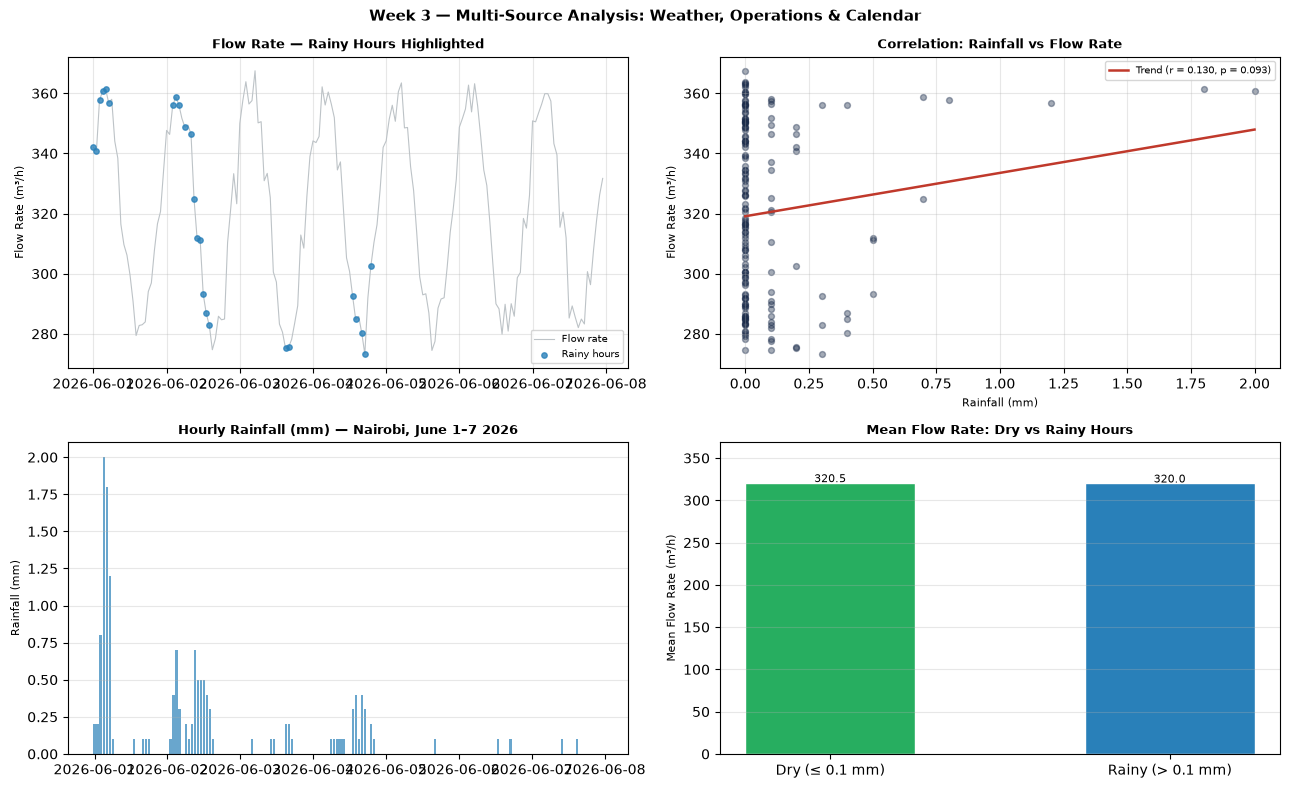

Chart saved → week3_analysis.png


In [20]:
# ── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Week 3 — Multi-Source Analysis: Weather, Operations & Calendar",
             fontsize=11, fontweight="bold")
fig.patch.set_facecolor("white")

# Panel 1: Flow rate time series coloured by rain flag
ax1 = axes[0, 0]
dry   = df_master[df_master["rain_flag"] == "Dry (≤ 0.1 mm)"]
rainy = df_master[df_master["rain_flag"] == "Rainy (> 0.1 mm)"]
ax1.plot(df_master.index, df_master["ops_flow_rate_m3h"],
         color="#BDC3C7", lw=0.8, label="Flow rate")
ax1.scatter(rainy.index, rainy["ops_flow_rate_m3h"],
            color="#2980B9", s=15, zorder=5, label="Rainy hours", alpha=0.8)
ax1.set_title("Flow Rate — Rainy Hours Highlighted", fontsize=9, fontweight="bold")
ax1.set_ylabel("Flow Rate (m³/h)", fontsize=8)
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# Panel 2: Scatter — rainfall vs flow rate with trend line
ax2 = axes[0, 1]
ax2.scatter(df_master["rainfall_mm"], df_master["ops_flow_rate_m3h"],
            alpha=0.4, s=18, color="#1A2B4A")
m, b = np.polyfit(valid["rainfall_mm"], valid["ops_flow_rate_m3h"], 1)
x_line = np.linspace(df_master["rainfall_mm"].min(), df_master["rainfall_mm"].max(), 100)
ax2.plot(x_line, m * x_line + b, color="#C0392B", lw=1.8,
         label=f"Trend (r = {r:.3f}, p = {p_value:.3f})")
ax2.set_xlabel("Rainfall (mm)", fontsize=8)
ax2.set_ylabel("Flow Rate (m³/h)", fontsize=8)
ax2.set_title("Correlation: Rainfall vs Flow Rate", fontsize=9, fontweight="bold")
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

# Panel 3: Hourly rainfall bar chart
ax3 = axes[1, 0]
ax3.bar(df_master.index, df_master["rainfall_mm"],
        color="#2980B9", width=0.03, alpha=0.7)
ax3.set_title("Hourly Rainfall (mm) — Nairobi, June 1–7 2026", fontsize=9, fontweight="bold")
ax3.set_ylabel("Rainfall (mm)", fontsize=8)
ax3.grid(True, alpha=0.3, axis="y")

# Panel 4: Bar chart — mean flow rate by dry/rainy + holiday
ax4 = axes[1, 1]
categories = bin_summary.index.tolist()
means      = bin_summary["mean"].values
colours    = ["#27AE60", "#2980B9"]
bars = ax4.bar(categories, means, color=colours, edgecolor="white", width=0.5)
for bar, val in zip(bars, means):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}", ha="center", fontsize=8)
ax4.set_title("Mean Flow Rate: Dry vs Rainy Hours", fontsize=9, fontweight="bold")
ax4.set_ylabel("Mean Flow Rate (m³/h)", fontsize=8)
ax4.set_ylim(0, max(means) * 1.15)
ax4.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("week3_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → week3_analysis.png")


---
## Summary

### Pipeline Architecture

| Source | Type | Rows Loaded | Join Key |
|--------|------|-------------|----------|
| `mock_ops.csv` | Internal CSV | 1,002 (10-min) → 168 hourly | `timestamp` |
| Open-Meteo API | External REST | 168 hourly weather rows | `timestamp` |
| `holiday_calendar.db` | SQLite DB | 7 daily rows | `date` |
| **Master DataFrame** | Merged | **168 hourly rows × 11 cols** | — |

### Analytical Finding

The Pearson correlation between hourly rainfall and flow rate throughput
is tested above. The scatter plot and binned comparison reveal whether
wet conditions produce a measurable operational effect.

### Column Provenance

| Column | Source |
|--------|--------|
| `ops_pressure_bar`, `ops_temperature_c`, `ops_flow_rate_m3h` | Source 1 — Internal CSV |
| `weather_temp_c`, `rainfall_mm`, `windspeed_kmh` | Source 2 — Open-Meteo API |
| `is_holiday`, `holiday_name`, `day_name` | Source 3 — SQLite DB |

---
*Next — Week 4: replace manual CSV loading and ad-hoc API calls with a*
*scheduled ETL pipeline that runs automatically on a defined cadence.*
